In [25]:
import pandas as pd

# Home prices
df = pd.read_csv("C:/Users/mandu/Downloads/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df.head()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Columns: 319 entries, RegionID to 2026-02-28
dtypes: float64(314), int64(2), object(3)
memory usage: 2.2+ MB


In [26]:
latest_month = df.columns[-1]

df = df[["RegionName", "StateName", latest_month]]

df.columns = ["City", "State", "Home_Price"]

df.head()

,City,State,Home_Price
0,United States,NaN,360590.988249
1,"New York, NY",NY,706888.193139
2,"Los Angeles, CA",CA,954296.088135
3,"Chicago, IL",IL,338685.299108
4,"Dallas, TX",TX,362141.885524


In [27]:
# Rent
rent_df = pd.read_csv("C:/Users/mandu/Downloads/Metro_zori_uc_sfrcondomfr_sm_month.csv")
latest_rent_month = rent_df.columns[-1]
rent_df = rent_df[["RegionName", latest_rent_month]]
rent_df.columns = ["City", "Rent_Price"]

# Merge
merged = pd.merge(df, rent_df, on = "City")
merged.head()

,City,State,Home_Price,Rent_Price
0,United States,NaN,360590.988249,1895.081429
1,"New York, NY",NY,706888.193139,3258.384200
2,"Los Angeles, CA",CA,954296.088135,2884.124775
3,"Chicago, IL",IL,338685.299108,2132.285104
4,"Dallas, TX",TX,362141.885524,1630.372571


In [28]:
# Model
# Price to Rent Ratio
merged["Rent_to_Price_Ratio"] = merged["Rent_Price"] / (merged["Home_Price"] * 12)

# Rent Yield %
merged["Rent_Yield"] = merged["Rent_Price"] / merged["Home_Price"] * 100

In [29]:
# Normalized values
merged["Normalized_Rent_to_Price_Ratio"] = (merged["Rent_to_Price_Ratio"] - merged["Rent_to_Price_Ratio"].min()) / (merged["Rent_to_Price_Ratio"].max() - merged["Rent_to_Price_Ratio"].min())
merged["Normalized_Rent_Yield"] = (merged["Rent_Yield"] - merged["Rent_Yield"].min()) / (merged["Rent_Yield"].max() - merged["Rent_Yield"].min())

# Investment score, weighted sum
merged["Investment_Score"] = 0.4 * merged["Normalized_Rent_to_Price_Ratio"] + 0.6 * merged["Normalized_Rent_Yield"]

# Investment score sorted by score descending
merged_sorted = merged.sort_values(by = "Investment_Score", ascending = False)

In [30]:
print(merged_sorted[["City", "State", "Home_Price", "Rent_Price", "Rent_to_Price_Ratio", "Rent_Yield", "Investment_Score"]].head(20))

                   City State     Home_Price   Rent_Price  \
470  Roanoke Rapids, NC    NC  101822.710778   990.000000   
657      Kingsville, TX    TX  149041.315832  1421.083333   
367         Decatur, IL    IL  119168.647447  1124.351852   
453        Danville, IL    IL   95095.298174   853.285714   
384        Meridian, MS    MS  120132.547521  1070.000000   
413      Orangeburg, SC    SC  151992.245300  1320.600000   
243         Abilene, TX    TX  204420.126143  1770.018538   
642      Big Spring, TX    TX  141289.822863  1207.222222   
636         Vidalia, GA    GA  166124.921898  1400.000000   
552           Ozark, AL    AL  156572.845422  1308.433333   
416          Elmira, NY    NY  149016.937150  1222.166667   
338       Lumberton, NC    NC  128022.674108  1045.833333   
604          McComb, MS    MS  102757.632121   837.000000   
494            Enid, OK    OK  137597.087112  1118.592593   
537      Enterprise, AL    AL  176019.659358  1422.432306   
441           Olean, NY 

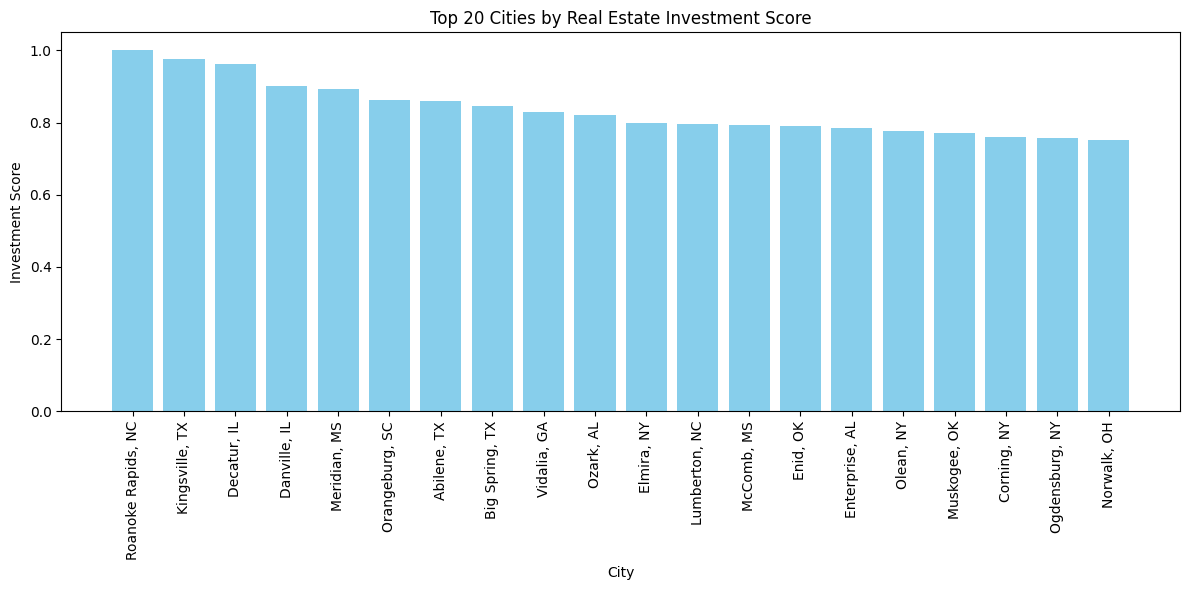

In [31]:
import matplotlib.pyplot as plt

# Bar chart
plt.figure(figsize = (12, 6))
plt.bar(merged_sorted["City"].head(20), merged_sorted["Investment_Score"].head(20), color = "skyblue")
plt.xticks(rotation = 90)
plt.xlabel("City")
plt.ylabel("Investment Score")
plt.title("Top 20 Cities by Real Estate Investment Score")
plt.tight_layout()
plt.show()


In [32]:
import streamlit as st

st.title("Real Estate Investment Analysis")

# User input: cities
selected_cities = st.multiselect("Select Cities", merged_sorted["City"].unique(), default = merged_sorted["City"].head(10).tolist())

# Filter data
filtered_data = merged_sorted[merged_sorted["City"].isin(selected_cities)].copy()

st.dataframe(filtered_data[["City", "State", "Home_Price", "Rent_Price", "Rent_to_Price_Ratio", "Rent_Yield", "Investment_Score"]])

# Bar chart
st.bar_chart(filtered_data.set_index("City")["Investment_Score"])

2026-03-17 16:22:28.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [33]:
# Popular Cities according to Zillow
popular_cities = pd.DataFrame({
    "City": ["Hartford, CT", "Buffalo, NY", "New York, NY", "Providence, RI", "San Jose, CA", "Philadelphia, PA", "Boston, MA",
             "Los Angeles, CA", "Richmond, VA", "Milwaukee, WI" ],
    "Source_Rank": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
})

comparison = pd.merge(popular_cities, merged_sorted, on = "City", how = "left")
st.write("Comparison of Popular Cities Ranked on Zillow")
st.dataframe(comparison[["City", "Investment_Score", "Source_Rank"]])

2026-03-17 16:22:28.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 16:22:28.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.markdown("""
## How the Model Works

The **Investment Score** is calculated as a weighted sum of:

- **Normalized Rent-to-Price Ratio**
- **Normalized Rent Yield**

Higher scores indicate cities where rental income is high relative to home price.

### Zillow Comparison
The table below compares our top 10 cities to Zillow's rankings.
""")